In [2]:
import polars as pl
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pl.read_csv('tugas5_ganjil.csv')

print("First 5 rows of the dataset:")
print(df.head().to_pandas())  # Convert to pandas for display

print("\nDataset Info:")
print(df.schema)  # Polars uses schema for info

print("\nMissing Values:")
print(df.null_count())

# Handle missing values by dropping rows with missing data
df = df.drop_nulls()
print("\nShape after handling missing values:", df.shape)

# Identify and encode categorical variables
categorical_cols = [col for col, dtype in df.schema.items() if dtype in [pl.Utf8, pl.Boolean]]
print("\nCategorical Columns:", categorical_cols)

First 5 rows of the dataset:
   ID  Age  Gender Region  Blood_Pressure  Cholesterol   BMI  Heart_Rate  \
0   1   50    Male  Rural           110.0        196.5  15.9          76   
1   2   40  Female  Urban           138.8        157.5  27.1          82   
2   3   26    Male  Rural           116.0        210.1  27.2          71   
3   4   54  Female  Rural           133.5        170.5  26.0          74   
4   5   19  Female  Urban           108.0        224.5  27.5          67   

  Exercise_Level  Smoking  ... Income_Level  Physical_Activity  \
0           High    False  ...          Low                Low   
1       Moderate    False  ...          Low           Moderate   
2       Moderate    False  ...       Middle               High   
3       Moderate     True  ...       Middle           Moderate   
4            Low    False  ...       Middle                Low   

   Education_Level  Marital_Status  Urban_Rural  Medication  Health_Awareness  \
0          Primary         Married  

In [4]:
label_encoders = {}
for col in categorical_cols:
    # Convert column to pandas Series for LabelEncoder
    pandas_series = df[col].fill_null("unknown").cast(pl.Utf8).to_pandas()
    le = LabelEncoder()
    encoded = le.fit_transform(pandas_series)
    df = df.with_columns(pl.Series(col, encoded))
    label_encoders[col] = le

print("\nData after encoding categorical variables:")
print(df.head().to_pandas())  # Convert to pandas for display

# Normalize numerical features
features = ['Age', 'Blood_Pressure', 'Cholesterol', 'BMI', 'Heart_Rate', 'Stress_Level', 'Sleep_Hours', 'Daily_Water_Intake']
X = df.select(features).to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nShape of scaled features:", X_scaled.shape)


Data after encoding categorical variables:
   ID  Age  Gender  Region  Blood_Pressure  Cholesterol   BMI  Heart_Rate  \
0   1   50       1       0           110.0        196.5  15.9          76   
1   2   40       0       2           138.8        157.5  27.1          82   
2   3   26       1       0           116.0        210.1  27.2          71   
3   4   54       0       0           133.5        170.5  26.0          74   
4   5   19       0       2           108.0        224.5  27.5          67   

   Exercise_Level  Smoking  ...  Income_Level  Physical_Activity  \
0               0        0  ...             1                  1   
1               2        0  ...             1                  2   
2               2        0  ...             2                  0   
3               2        1  ...             2                  2   
4               1        0  ...             2                  1   

   Education_Level  Marital_Status  Urban_Rural  Medication  Health_Awareness  \
0  

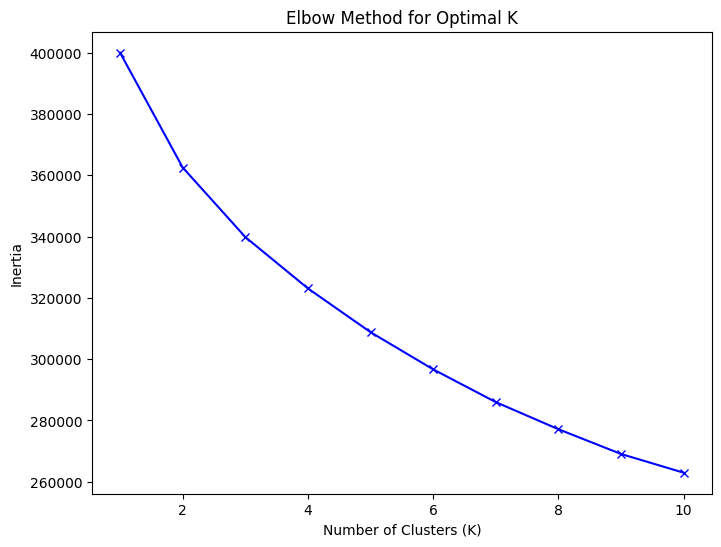

In [5]:
# 2. K-Means Clustering
# Elbow Method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

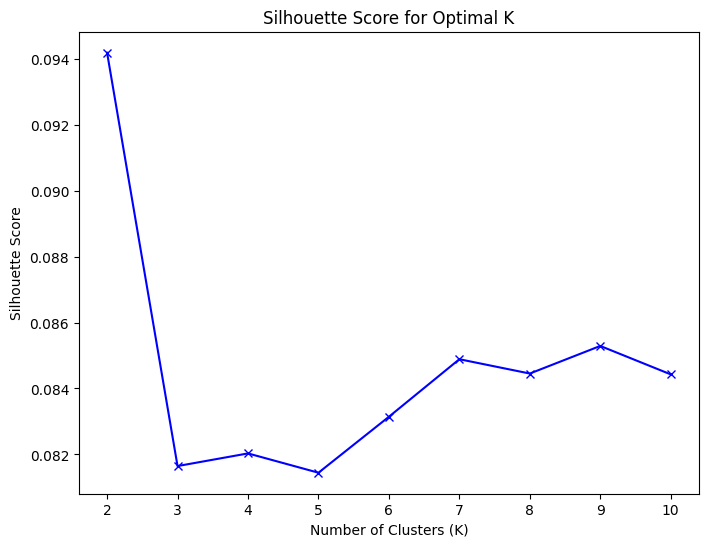

In [6]:
# Silhouette Score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.show()

In [7]:
# Simplified Gap Statistics
def compute_gap_statistic(X_scaled, k_range, n_refs=5, random_state=42):
    gaps = np.zeros(len(k_range))
    for i, k in enumerate(k_range):
        kmeans = KMeans(n_clusters=k, random_state=random_state)
        kmeans.fit(X_scaled)
        disp = kmeans.inertia_
        ref_disps = np.zeros(n_refs)
        for j in range(n_refs):
            random_data = np.random.random_sample(size=X_scaled.shape)
            kmeans_ref = KMeans(n_clusters=k, random_state=random_state)
            kmeans_ref.fit(random_data)
            ref_disps[j] = kmeans_ref.inertia_
        gaps[i] = np.mean(np.log(ref_disps)) - np.log(disp)
    return gaps

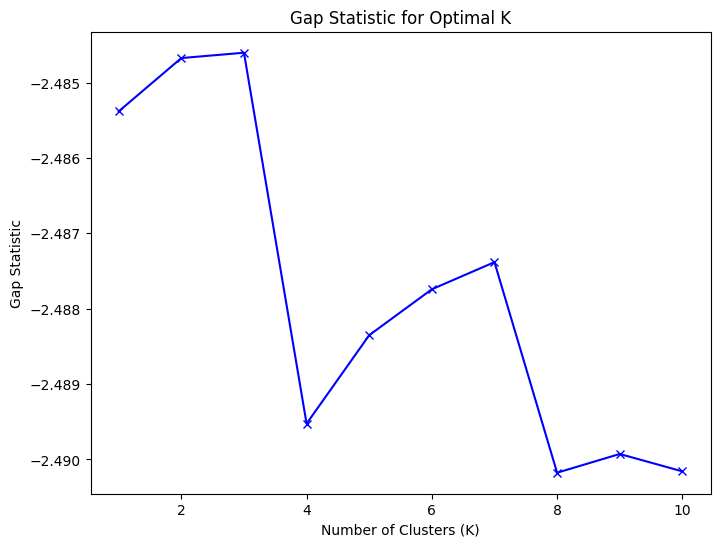

In [8]:
k_range = range(1, 11)
gaps = compute_gap_statistic(X_scaled, k_range)
plt.figure(figsize=(8, 6))
plt.plot(k_range, gaps, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic for Optimal K')
plt.show()

In [9]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df = df.with_columns(pl.Series('KMeans_Cluster', kmeans_labels))

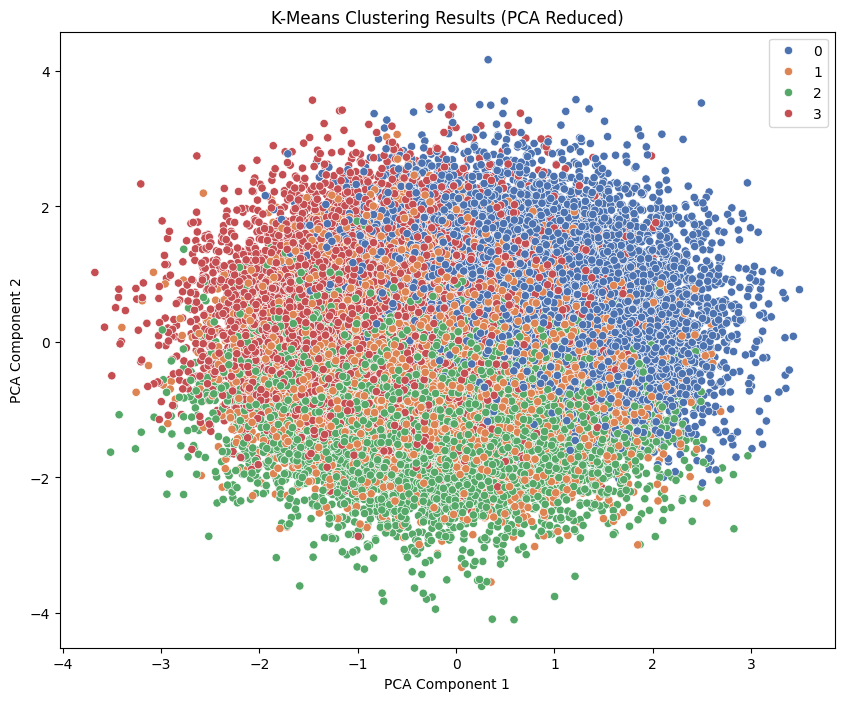

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='deep')
plt.title('K-Means Clustering Results (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [11]:
cluster_summary = df.group_by('KMeans_Cluster').agg(pl.mean_horizontal(*features))
print("\nCluster Summary (Mean Values):")
print(cluster_summary.to_pandas())
print("\nInterpretation: The K-Means clustering with K=4 groups patients into four clusters based on health metrics. Clusters may represent different health profiles (e.g., high-stress vs. low-stress groups) depending on mean values of features like Stress_Level, Sleep_Hours, and BMI.")


Cluster Summary (Mean Values):
   KMeans_Cluster                                                Age
0               0  [57.05, 64.1375, 59.875, 63.0625, 53.4, 60.075...
1               3  [58.512499999999996, 57.6125, 65.1125, 57.0125...
2               1  [59.2375, 61.625, 67.9375, 71.2, 59.575, 53.51...
3               2  [58.68749999999999, 61.5625, 62.15000000000000...

Interpretation: The K-Means clustering with K=4 groups patients into four clusters based on health metrics. Clusters may represent different health profiles (e.g., high-stress vs. low-stress groups) depending on mean values of features like Stress_Level, Sleep_Hours, and BMI.


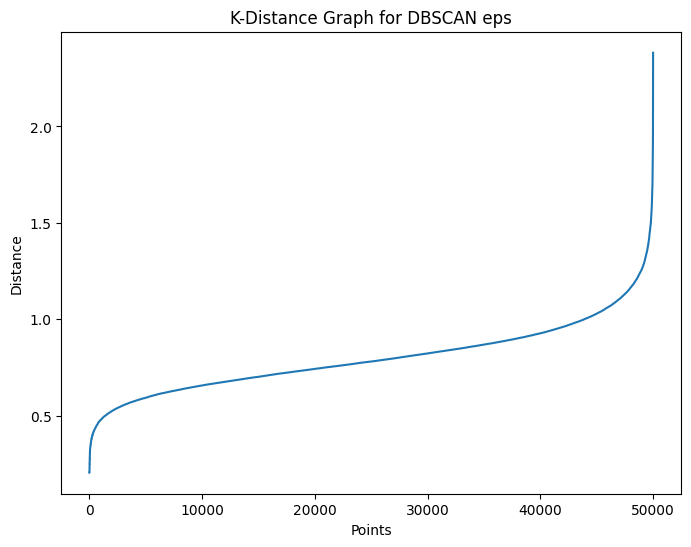

In [12]:
# Determine eps using K-Distance Graph
neighbors = NearestNeighbors(n_neighbors=2 * len(features))
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 1], axis=0)

plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.title('K-Distance Graph for DBSCAN eps')
plt.xlabel('Points')
plt.ylabel('Distance')
plt.show()

In [13]:
# Apply DBSCAN with estimated eps (e.g., 0.5) and min_samples
dbscan = DBSCAN(eps=0.5, min_samples=2 * len(features))
dbscan_labels = dbscan.fit_predict(X_scaled)

# Add DBSCAN labels to dataframe
df = df.with_columns(pl.Series('DBSCAN_Cluster', dbscan_labels))

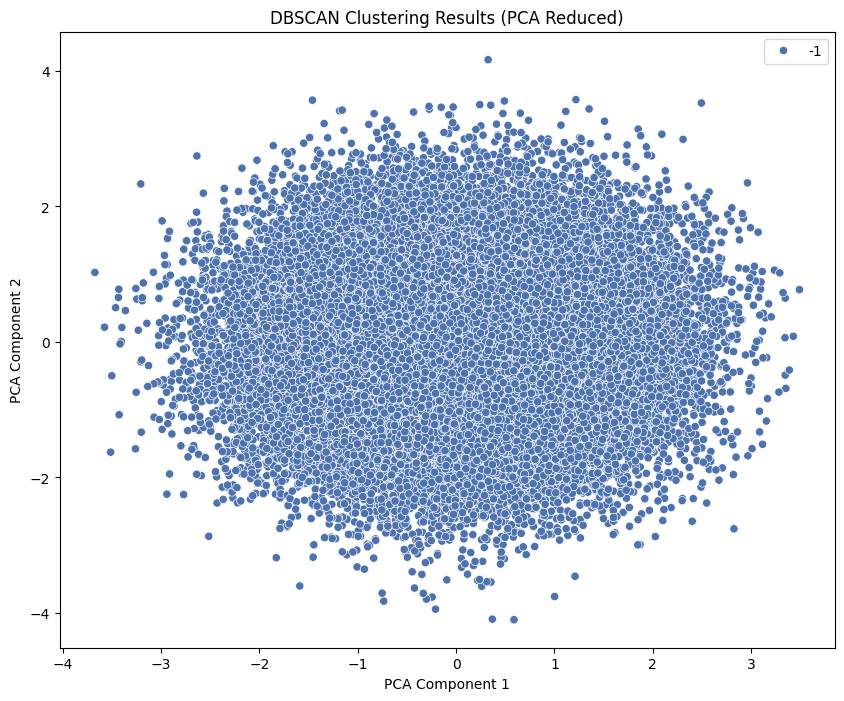

In [14]:
# Visualize DBSCAN results with PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='deep')
plt.title('DBSCAN Clustering Results (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [15]:
# Compare K-Means and DBSCAN
print("\nComparison of K-Means and DBSCAN:")
print("K-Means Clusters:")
print(df.group_by('KMeans_Cluster').agg(pl.count()).to_pandas())
print("\nDBSCAN Clusters:")
print(df.group_by('DBSCAN_Cluster').agg(pl.count()).to_pandas())
print("\nInterpretation: K-Means assigns all points to 4 clusters, suitable for structured data with clear groups. DBSCAN may label some points as noise (-1), better for detecting outliers or irregularly shaped clusters. K-Means assumes spherical clusters, while DBSCAN handles varying shapes but requires careful tuning of eps and min_samples.")


Comparison of K-Means and DBSCAN:
K-Means Clusters:
   KMeans_Cluster  count
0               0  13050
1               3  11966
2               2  12360
3               1  12624

DBSCAN Clusters:
   DBSCAN_Cluster  count
0              -1  50000

Interpretation: K-Means assigns all points to 4 clusters, suitable for structured data with clear groups. DBSCAN may label some points as noise (-1), better for detecting outliers or irregularly shaped clusters. K-Means assumes spherical clusters, while DBSCAN handles varying shapes but requires careful tuning of eps and min_samples.
